Use this script to look at the fraction of tuned cells to different variables in different conditions by plotting their tuning curve and full escape matrix heatmap

- sig tuned to %escape and shelter distance in explore
- sig tuned to %escape and shelter distance in homing/escape
- triple overlap cells

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

In [26]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.escape.escape_plotting_funcs import plot_tuning_matrix

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
comp = 'escape'
exp = experiments_objects[7]
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                fcm, 
                                                                                behave, 
                                                                                y_pos, x_pos, 
                                                                                bar, 
                                                                                barflip, 
                                                                                comp, 
                                                                                ons, offs, 
                                                                                no_stationary = False, 
                                                                                return_escape = True,
                                                                                zscore = False)

2025-02-27 09:52:51.455 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


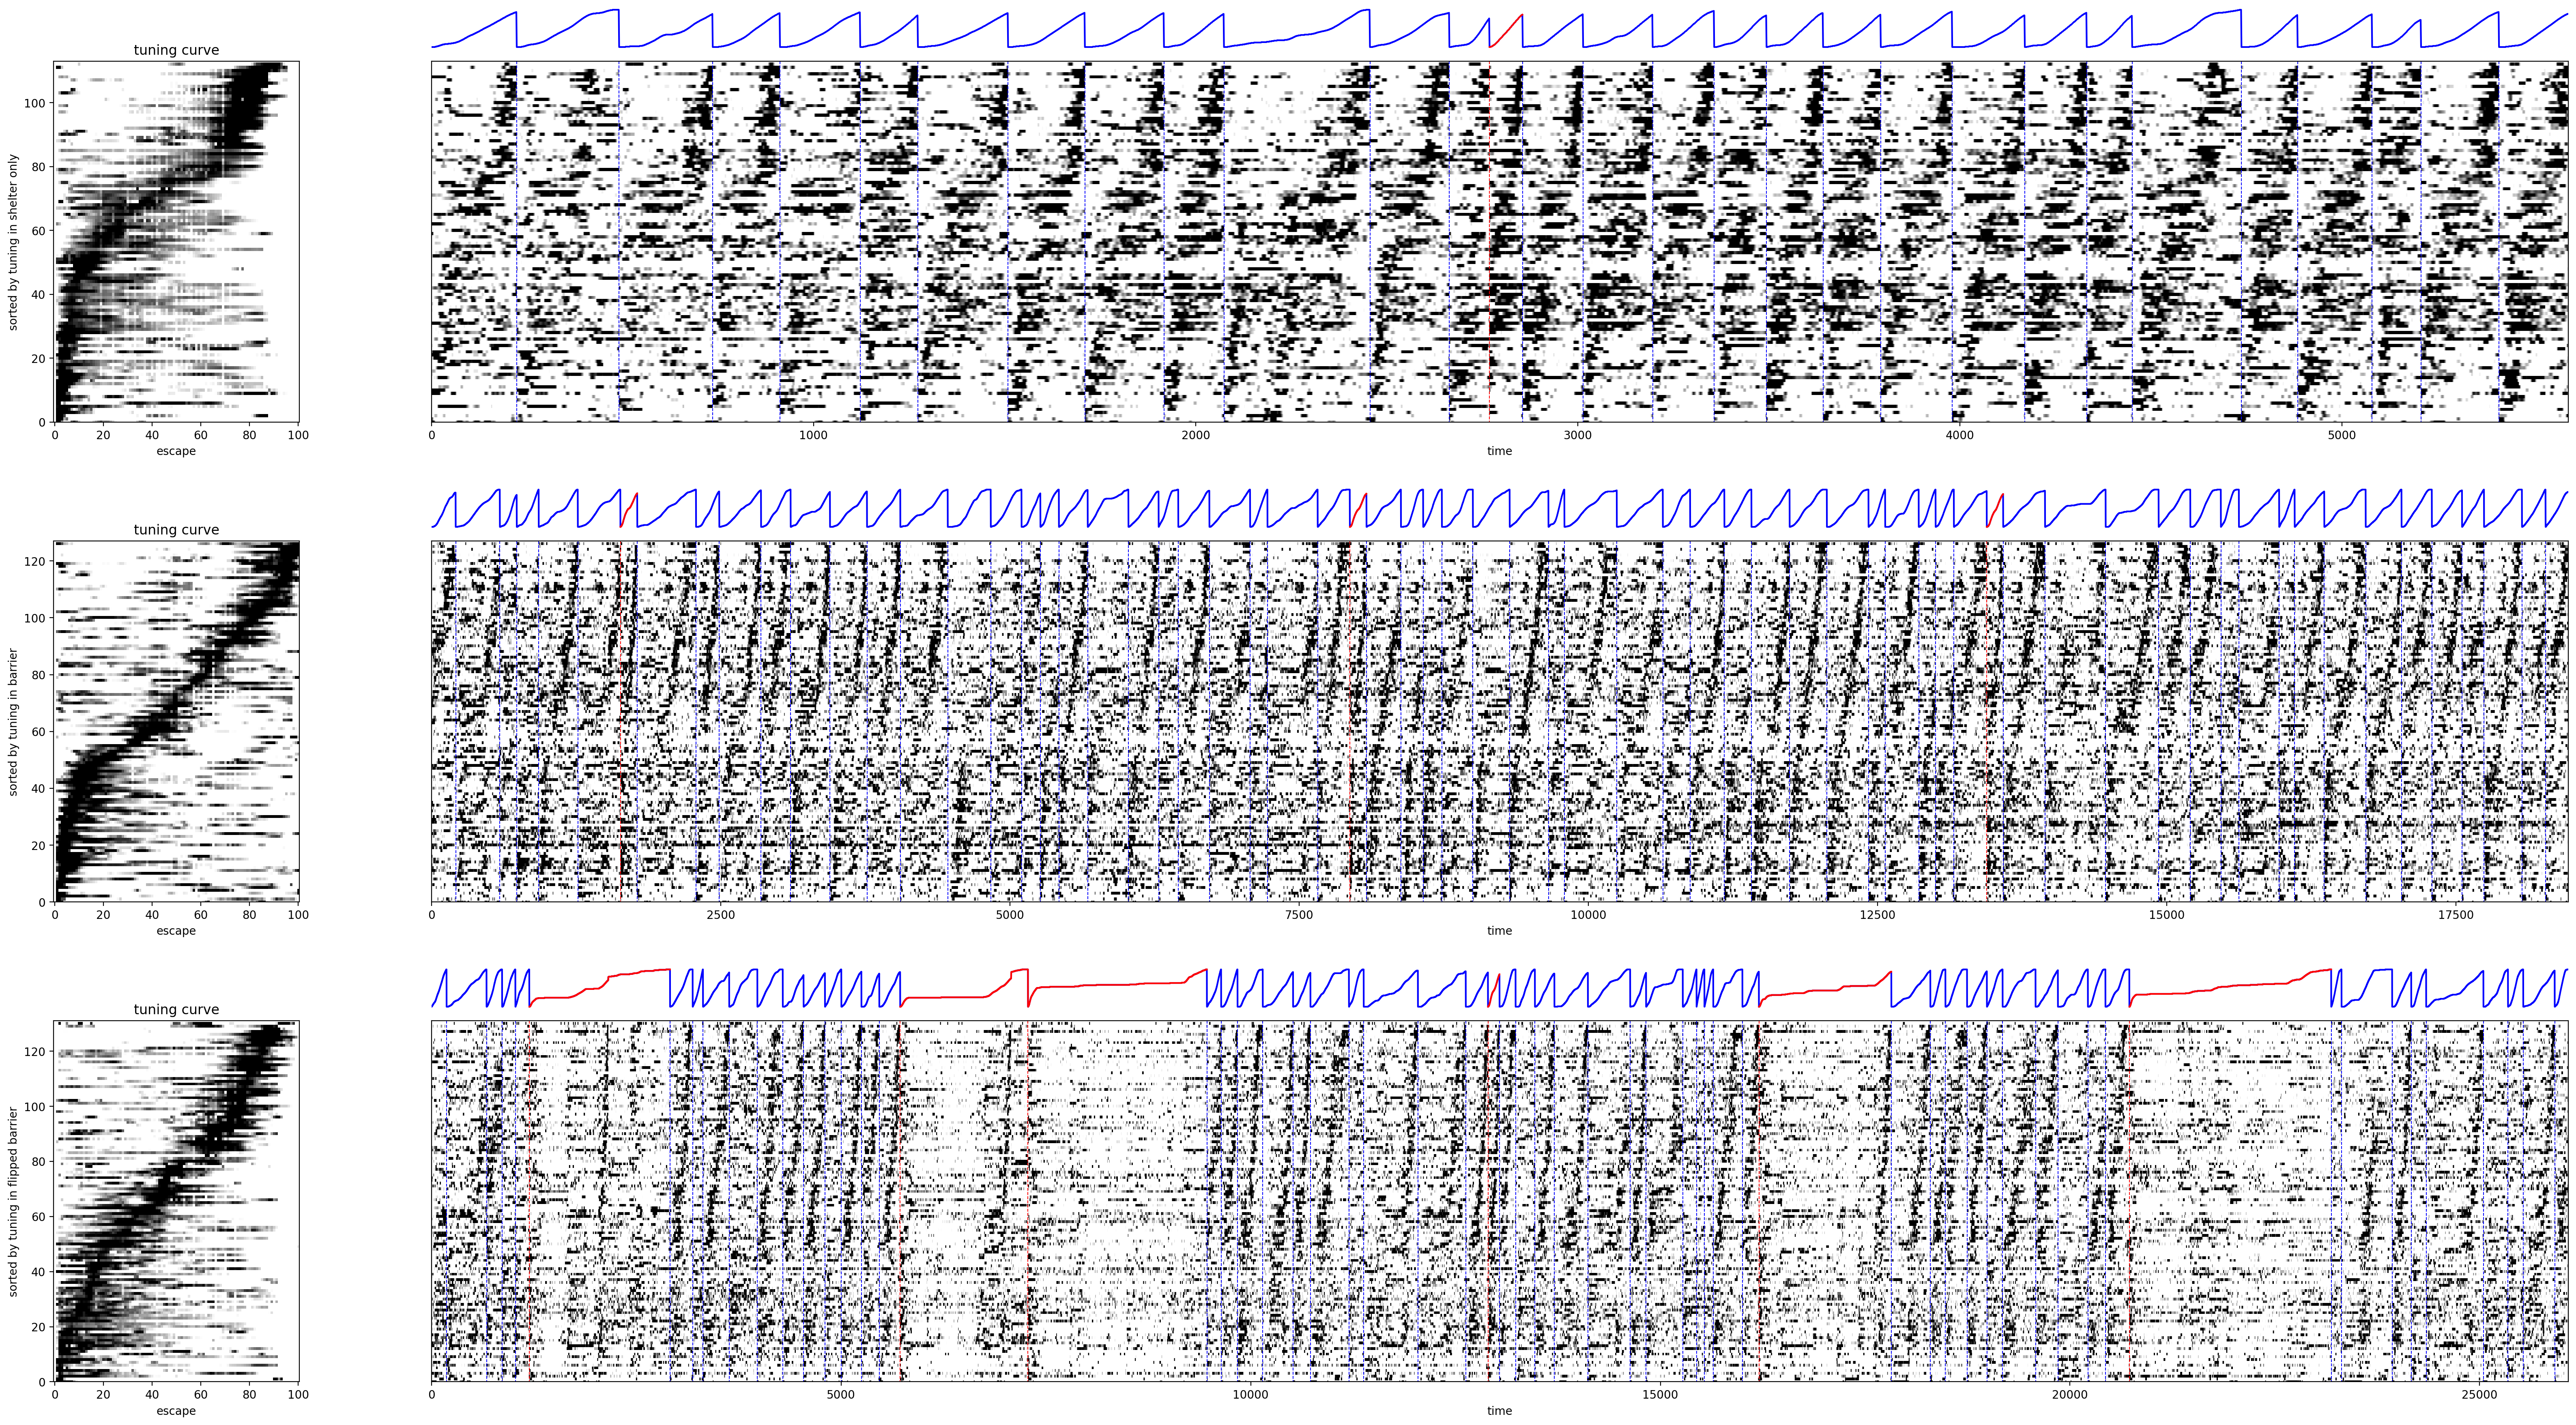

In [28]:
"""How many cells are tuned only to the %escape and not to the distance to shelter in exploration?
Using residuals to identify tuning to %escape surviving from distance to shelter subtraction"""
%matplotlib inline
%autoreload 2

nickname = exp.nick_name + '_' + exp.experiment_date
c_names = ['shelter_only', 'barrier', 'flipped_barrier']

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
saving_file = dump_path + exp_nickname + '_Tuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
exp_params_real = data['params_real']
exp_params_shifts = data['params_shifts']

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
fr_real = data['fr_real']
params_real = data['params_real']
params_shifts = data['params_shifts']

# load in residuals data
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ResidualsTuning.npz'
data = np.load(saving_file)
data_files = data.files
params_real_exp = data['params_real_exp']
params_shifts_exp_res = data['params_shifts_exp_res']

# identify cells that are sig tuned to %escape in homing/escape
sig_escape = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# identify cells that are sig tuned to distance to shelter in exploration
exp_sig_dist = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)

# identify significant cells of interest to create xval matrix of length neurons x conditions
xval = np.full_like(sig_escape, np.nan)
for c in range(3):
    A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)  # V1 only
    AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True)  # Both V1 and V1 regressed
    xval[:,c] = (A == True) | (AC == True)

# peak_firing_condition: is a matrix of neurons x condition, where each entry is the bin that neuron is tuned to in that condition to the behavioral variable
peak_firing_condition = params_real[:,:,1]

# tuning_matrix: is a list of len(conditions), each entry is a matrix of tuning curves of shape neurons x bins
tuning_matrix = [zscore(t, axis = 1) for t in fr_real]

"""Raster heatmap"""
plot_tuning_matrix(tuning_matrix, cond, comp, zscore(escape_matrix, axis = 1), var, esc_start, h_start, xval, nickname = exp_nickname + '_ResidualTuning', peak_firing_condition = [], dump_path = "Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname, show = True)

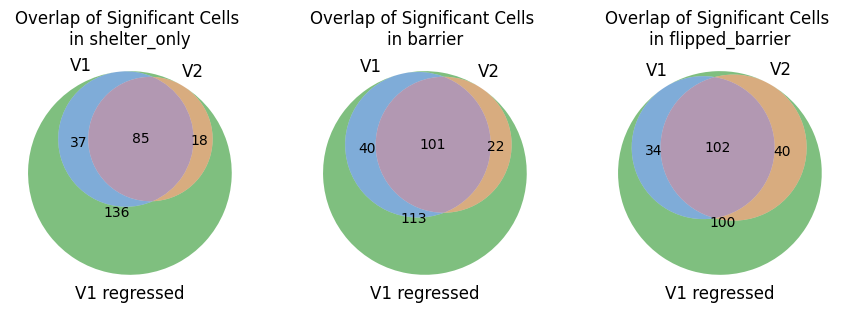

In [18]:
"""How many cells are tuned to the %escape and to the distance to shelter in homing/escape?"""

nickname = exp.nick_name + '_' + exp.experiment_date
c_names = ['shelter_only', 'barrier', 'flipped_barrier']

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
dist_params_real = data['params_real']
dist_params_shifts = data['params_shifts']

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
params_real = data['params_real']
params_shifts = data['params_shifts']

# TODO: load in results from TunED


# identify cells that are sig tuned to %escape in homing/escape
sig_escape = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# identify cells that are sig tuned to distance to shelter in exploration
sig_dist = dist_params_real[:,:,0] > np.nanpercentile(dist_params_shifts[:,:,:,0], 95, axis = 0)

# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
# sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)
tuned_sig = np.full_like(sig_dist, True)

"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    # Compute Set Sizes
    A = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == False))  # V1 only
    B = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == False))  # V2 only
    C = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == True))  # V1 regressed
    AB = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == False))  # Both V1 and V2
    AC = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=('V1', 'V2', 'TunED V1'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()